In [1]:
import pandas as pd
import huggingface_hub as hf

import plotly.express as px
import plotly.io as pio

pio.templates.default = 'plotly_white'

In [2]:
iris_path = hf.hf_hub_download("scikit-learn/iris", "Iris.csv", 
                               repo_type="dataset")
iris_path

'/Users/shmuma/.cache/huggingface/hub/datasets--scikit-learn--iris/snapshots/0bda0ce801be0fa2f464ff845a9d5ceae99aad7d/Iris.csv'

In [3]:
df = pd.read_csv(iris_path)

In [4]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df['Species'].dtype

<StringDtype(storage='python', na_value=nan)>

In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
df.drop('Id', axis=1, inplace=True)

# Plotting

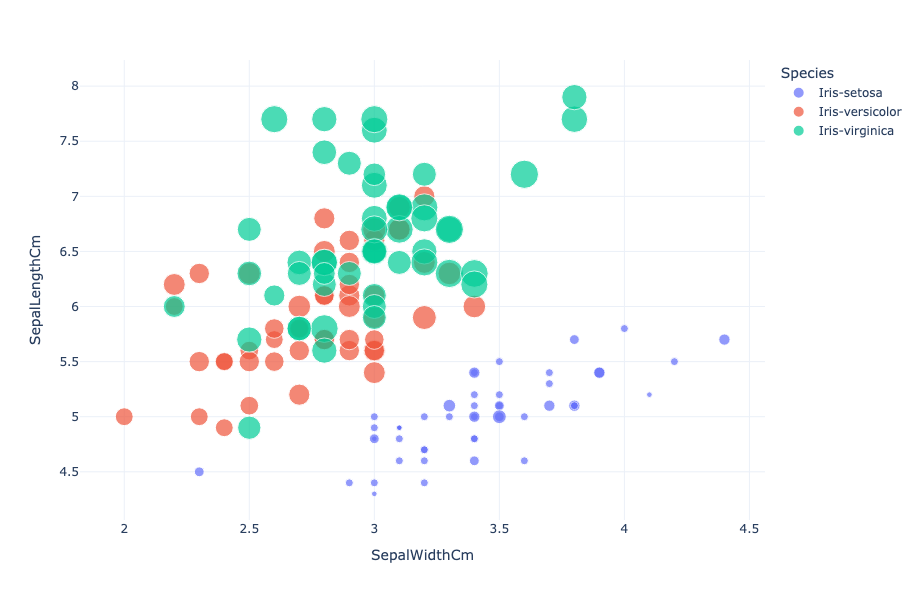

In [9]:
px.scatter(df, x="SepalWidthCm", y="SepalLengthCm", 
           color="Species", size="PetalWidthCm", 
           width=800, height=600)

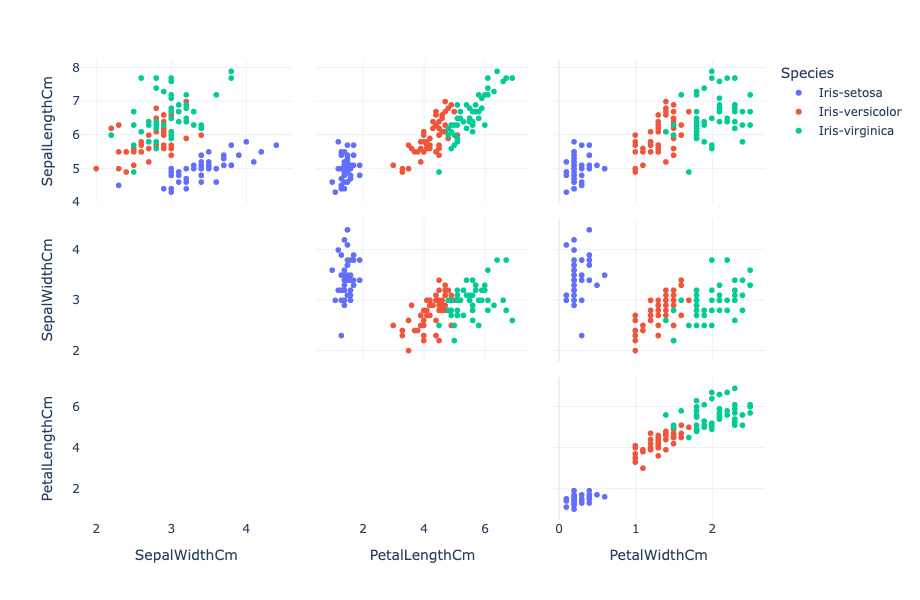

In [10]:
fig = px.scatter_matrix(
    df, color='Species', width=800, height=600,
    dimensions=["SepalLengthCm", "SepalWidthCm", 
                "PetalLengthCm", "PetalWidthCm"]
)
fig.update_traces(diagonal_visible=False, showlowerhalf=False)

In [11]:
outlier_cond = (df.SepalWidthCm <= 2.3) & (df.Species == 'Iris-setosa') | \
               (df.SepalLengthCm <= 4.9) & (df.Species == 'Iris-virginica')
print(df[outlier_cond])
df.drop(df[outlier_cond].index, inplace=True)
df.shape

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
41             4.5           2.3            1.3           0.3     Iris-setosa
106            4.9           2.5            4.5           1.7  Iris-virginica


(148, 5)

In [12]:
df.isna().any()

SepalLengthCm    False
SepalWidthCm     False
PetalLengthCm    False
PetalWidthCm     False
Species          False
dtype: bool

# Data preprocessing

In [13]:
one_hot_df = pd.get_dummies(df, columns=["Species"], 
                            prefix="class", dtype=int)
one_hot_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,class_Iris-setosa,class_Iris-versicolor,class_Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,0,1
146,6.3,2.5,5.0,1.9,0,0,1
147,6.5,3.0,5.2,2.0,0,0,1
148,6.2,3.4,5.4,2.3,0,0,1


In [14]:
train_df = one_hot_df[["SepalLengthCm", "SepalWidthCm", 
                       "PetalLengthCm", "PetalWidthCm"]]
train_df.to_numpy()[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])